In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [20]:
df=pd.read_csv('Student_Performance.csv')

In [3]:
df.sample(5)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
6572,5,99,Yes,4,0,86.0
6956,3,71,Yes,5,9,50.0
1029,2,44,Yes,4,5,17.0
3360,9,44,No,5,8,42.0
84,7,80,No,8,3,71.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [5]:
df.shape

(10000, 6)

In [6]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [7]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [8]:
df.nunique()

Hours Studied                        9
Previous Scores                     60
Extracurricular Activities           2
Sleep Hours                          6
Sample Question Papers Practiced    10
Performance Index                   91
dtype: int64

In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
le=LabelEncoder()

In [21]:
df['Extracurricular Activities']=df['Extracurricular Activities'].map({'Yes':1,'No':0})

<Axes: xlabel='Extracurricular Activities', ylabel='Performance Index'>

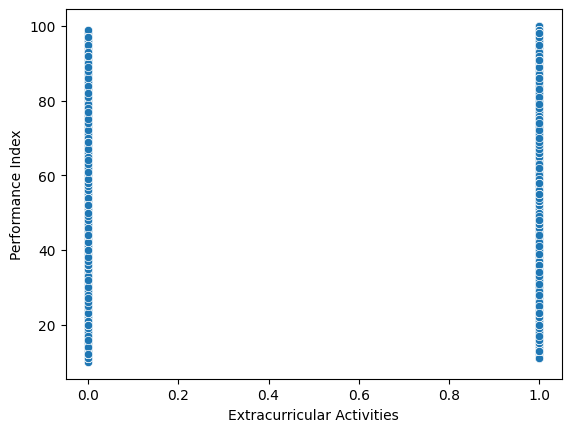

In [26]:
sns.scatterplot(x=df['Extracurricular Activities'],y=df['Performance Index'])

In [12]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,1,4,2,23.0
9996,7,64,1,8,5,58.0
9997,6,83,1,8,5,74.0
9998,9,97,1,7,0,95.0


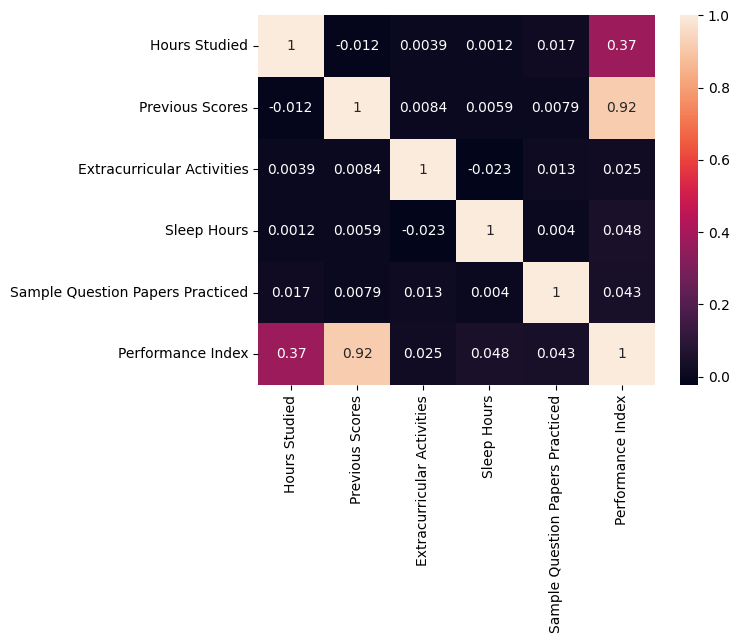

In [13]:

sns.heatmap(df.corr(), annot=True)
plt.show()

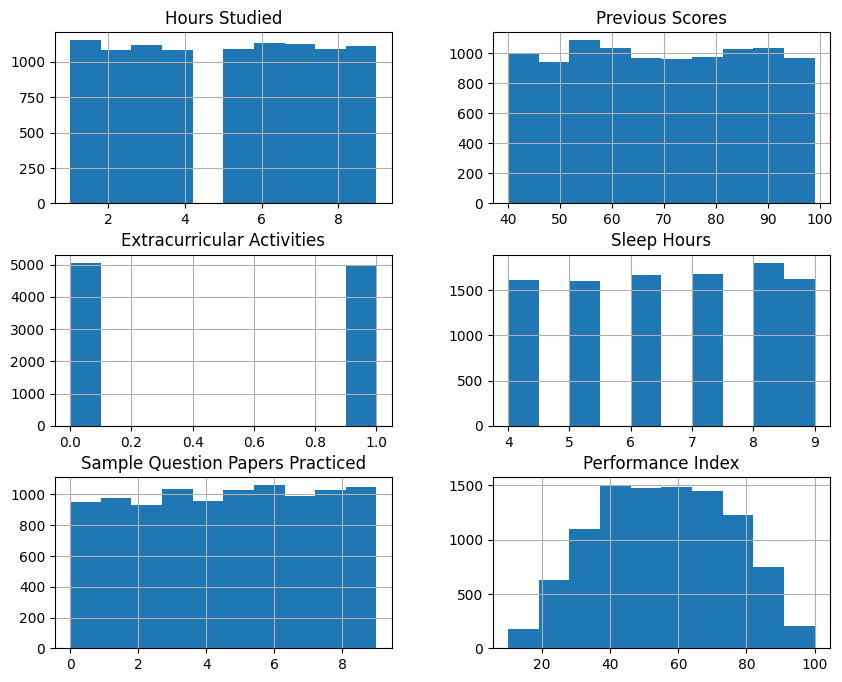

In [14]:
df.hist(figsize=(10,8))
plt.show()

In [15]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [18]:
x = df.drop('Performance Index', axis=1)
y = df['Performance Index']

In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
9254,5,49,0,7,5
1561,2,48,1,7,6
1670,2,81,0,7,2
6087,2,46,0,6,1
6669,8,47,0,9,0
...,...,...,...,...,...
5734,8,50,1,6,6
5191,4,68,0,9,3
5390,9,48,0,7,6
860,1,47,0,9,0


In [ ]:
sns.scatterplot(x=df['Hours Studied'],y=df[''])

In [166]:
x_train

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
9254,5,49,0,7,5
1561,2,48,1,7,6
1670,2,81,0,7,2
6087,2,46,0,6,1
6669,8,47,0,9,0
...,...,...,...,...,...
5734,8,50,1,6,6
5191,4,68,0,9,3
5390,9,48,0,7,6
860,1,47,0,9,0


In [167]:
num_features = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']
cat_features = ['Extracurricular Activities']
 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor=ColumnTransformer([
    ('num',StandardScaler(),num_features),
    ('cat', 'passthrough', cat_features)
])

x_train=preprocessor.fit_transform(x_train)
x_test=preprocessor.fit_transform(x_test)

In [116]:
x_train

array([[ 0.00645547, -1.18384439,  0.26988848,  0.13404112,  0.        ],
       [-1.14974745, -1.24150571,  0.26988848,  0.48356164,  1.        ],
       [-1.14974745,  0.66131759,  0.26988848, -0.91452044,  0.        ],
       ...,
       [ 1.54805935, -1.24150571,  0.26988848,  0.48356164,  0.        ],
       [-1.53514842, -1.29916702,  1.4474766 , -1.61356148,  0.        ],
       [-1.14974745, -1.35682833, -0.31890558,  0.48356164,  0.        ]],
      shape=(8000, 5))

In [117]:
x_test

array([[-0.01227298, -0.0060277 ,  0.89844227, -0.84856166,  0.        ],
       [-1.1811281 , -1.33269881, -1.4760335 ,  1.22912451,  1.        ],
       [ 0.76696377, -0.75588528,  0.30482333,  0.19028142,  1.        ],
       ...,
       [-1.1811281 , -1.67878692,  0.30482333, -0.84856166,  1.        ],
       [-0.79150973,  0.80151123,  0.30482333,  0.19028142,  0.        ],
       [-0.01227298, -0.52515987,  0.89844227, -0.1559996 ,  0.        ]],
      shape=(2000, 5))

In [118]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()

In [119]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [120]:
y_pred=lr.predict(x_test)

In [121]:
y_pred

array([55.07535439, 22.85093944, 48.31523685, ..., 17.049118  ,
       63.64005153, 46.29938638], shape=(2000,))

In [122]:
y_test

6252    51.0
4684    20.0
1731    46.0
4742    28.0
4521    41.0
        ... 
6412    45.0
8285    66.0
7853    16.0
1095    65.0
6929    47.0
Name: Performance Index, Length: 2000, dtype: float64

In [123]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 2.0660069262393455


In [125]:
from sklearn.metrics import r2_score

r2=r2_score(y_test, y_pred)
print("R2:",r2)

R2: 0.9884820397933387


In [127]:
print(lr.coef_)
print(lr.intercept_)

[ 7.40134079 17.63727127  0.81003107  0.54884171  0.60861668]
55.010462974864524


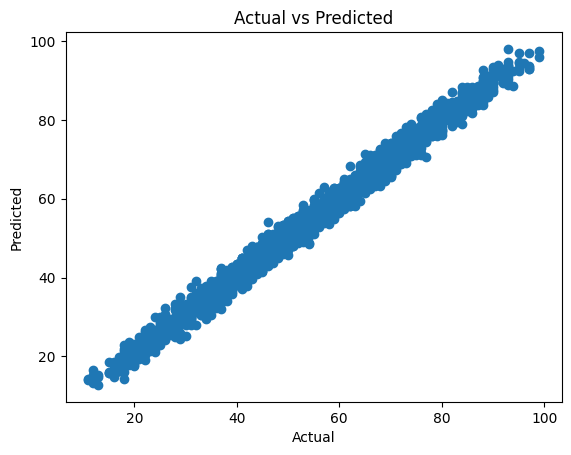

In [128]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [138]:
X = df[['Hours Studied', 'Sleep Hours', 'Sample Question Papers Practiced','Extracurricular Activities']]
Y=df['Performance Index']

In [139]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [140]:
num_features = ['Hours Studied',  'Sleep Hours', 'Sample Question Papers Practiced']
cat_features = ['Extracurricular Activities']
 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor=ColumnTransformer([
    ('num',StandardScaler(),num_features),
    ('cat', 'passthrough', cat_features)
])

X_train=preprocessor.fit_transform(X_train)
X_test=preprocessor.fit_transform(X_test)

In [141]:
X_train

array([[ 0.00645547,  0.26988848,  0.13404112,  0.        ],
       [-1.14974745,  0.26988848,  0.48356164,  1.        ],
       [-1.14974745,  0.26988848, -0.91452044,  0.        ],
       ...,
       [ 1.54805935,  0.26988848,  0.48356164,  0.        ],
       [-1.53514842,  1.4474766 , -1.61356148,  0.        ],
       [-1.14974745, -0.31890558,  0.48356164,  0.        ]],
      shape=(8000, 4))

In [142]:
from sklearn.linear_model import LinearRegression

lr2=LinearRegression()

In [143]:
lr2.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [144]:
Y_pred=lr2.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
print("RMSE:", rmse)

RMSE: 17.872958432968684


In [146]:
from sklearn.metrics import r2_score

r2=r2_score(Y_test, Y_pred)
print("R2:",r2)

R2: 0.13800465978070642


In [168]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

In [169]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("RF RMSE:", rmse_rf)
print("RF R2:", r2_rf)

RF RMSE: 2.279477656551967
RF R2: 0.9859788799863197


In [171]:
import pandas as pd

importance = rf.feature_importances_

feature_names = X.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feat_imp)

                            Feature  Importance
1                   Previous Scores    0.847028
0                     Hours Studied    0.141622
3                       Sleep Hours    0.005188
2        Extracurricular Activities    0.004818
4  Sample Question Papers Practiced    0.001343


In [173]:
# Training performance
y_train_pred = rf.predict(x_train)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Train RMSE: 0.9678796966175965
Test RMSE: 2.279477656551967


In [174]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, scoring='neg_mean_squared_error', cv=5)

rmse_scores = np.sqrt(-scores)

print("CV RMSE:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())

CV RMSE: [2.37208879 2.31779824 2.32206734 2.35139586 2.33995186]
Mean RMSE: 2.3406604148952
